In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## GRU

### Battery Drain Comparison

#### Statistics

In [2]:
df = pd.read_csv("./API_GRU.csv")
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,battery_drain,predicted_drain_average,inference_time_ms,batch
0,5/1/2026 10:38,55,65,38.0,50,0,8.770573,122.754200,1,23,-660,-333.01575,4169.728176,1
1,5/1/2026 10:38,55,65,38.0,50,0,8.770573,122.754200,1,23,-660,-336.80630,176.724687,1
2,5/1/2026 10:38,42,66,38.0,50,0,8.381533,59.084347,1,23,-390,-342.35532,176.040885,1
3,5/1/2026 10:38,39,66,38.0,50,0,3.413585,53.422348,1,23,-395,-344.14853,139.490208,1
4,5/1/2026 10:38,35,67,38.0,50,0,6.425407,108.144870,1,23,-286,-345.38885,118.480416,1


In [3]:
shift_step = 15
df_eval = df.copy()
df_eval['actual_aligned'] = df_eval['battery_drain'].shift(-shift_step)
df_eval = df_eval.dropna(subset=['actual_aligned', 'predicted_drain_average'])

In [4]:
df_eval[['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             83.056387
predicted_drain_average    21.212645
dtype: float64

In [5]:
# Not Charging
df_eval[df_eval['battery_charging'] != 1][
    ['actual_aligned', 'predicted_drain_average']
].mean()

actual_aligned            -268.435196
predicted_drain_average   -340.169942
dtype: float64

In [6]:
# Charging
df_eval[df_eval['battery_charging'] == 1][
    ['actual_aligned', 'predicted_drain_average']
].mean()

actual_aligned             1803.297549
predicted_drain_average    1789.861543
dtype: float64

In [7]:
charging = df_eval[df_eval['battery_charging'] == 1]
not_charging = df_eval[df_eval['battery_charging'] != 1]

In [8]:
def percentage_diff(df):
    actual_mean = df['actual_aligned'].mean()
    pred_mean = df['predicted_drain_average'].mean()

    perc = abs(actual_mean - pred_mean) / abs(actual_mean) * 100

    return actual_mean, pred_mean, perc

In [9]:
act_c, pred_c, perc_c = percentage_diff(charging)
act_nc, pred_nc, perc_nc = percentage_diff(not_charging)
act_all, pred_all, perc_all = percentage_diff(df_eval)

In [10]:
print("== ALL ===")
print("Actual Mean:", act_all)
print("Predicted Mean:", pred_all)
print("Percentage Difference:", perc_all, "%")

print("\n=== CHARGING ===")
print("Actual Mean:", act_c)
print("Predicted Mean:", pred_c)
print("Percentage Difference:", perc_c, "")

print("\n=== NOT CHARGING ===")
print("Actual Mean:", act_nc)
print("Predicted Mean:", pred_nc)
print("Percentage Difference:", perc_nc, "%")

== ALL ===
Actual Mean: 83.0563872255489
Predicted Mean: 21.212645338656014
Percentage Difference: 74.4599469742758 %

=== CHARGING ===
Actual Mean: 1803.297549019608
Predicted Mean: 1789.8615427058821
Percentage Difference: 0.7450798300607954 

=== NOT CHARGING ===
Actual Mean: -268.43519631410254
Predicted Mean: -340.169941863782
Percentage Difference: 26.723301018149986 %


#### Graph

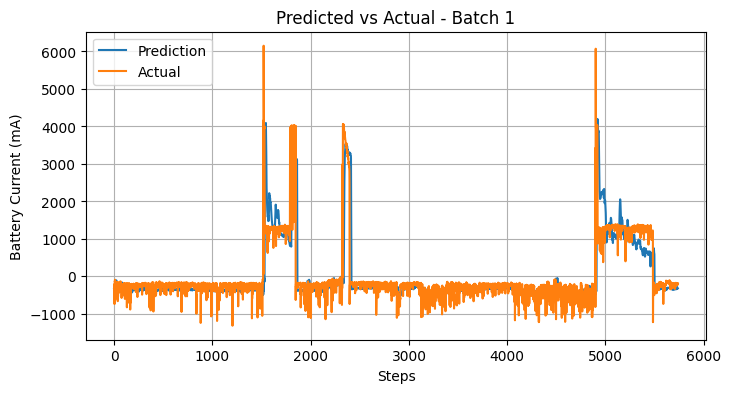

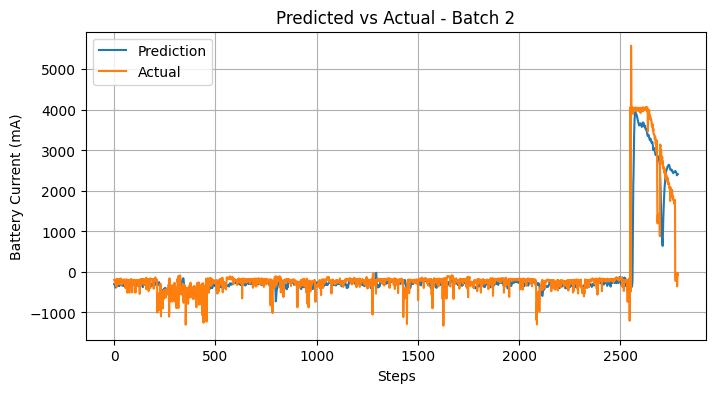

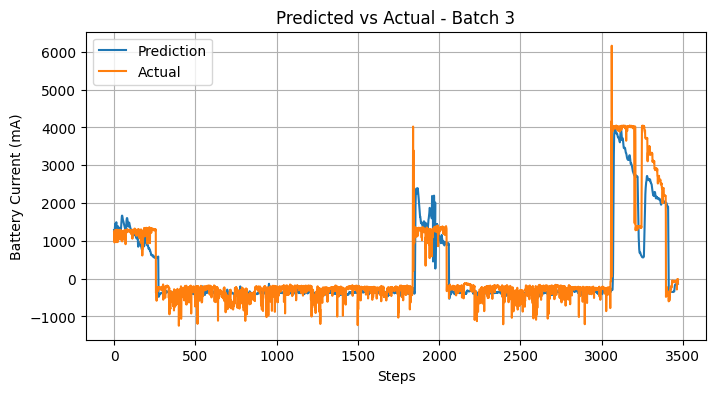

In [11]:
# Predicted vs Actual Graph
batch_num = df['batch'].nunique()

for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    plt.figure(figsize=(8, 4))
    plt.plot(predicted, label="Prediction")
    plt.plot(actual, label="Actual")
    plt.title(f"Predicted vs Actual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Battery Current (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

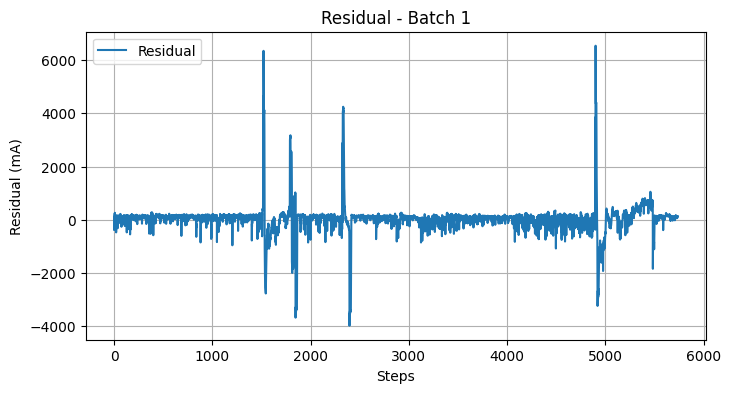

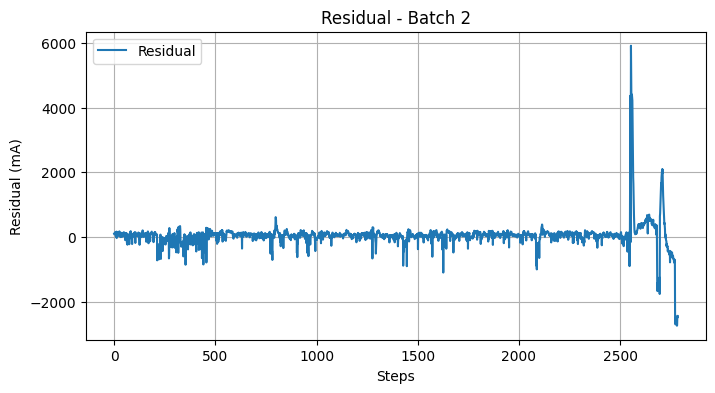

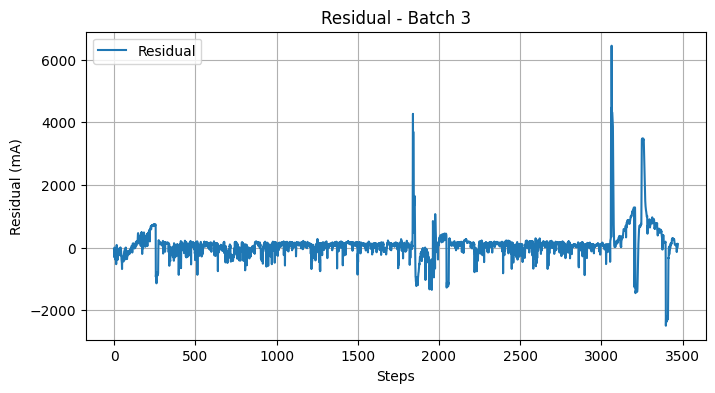

In [12]:
# Residual Graph
for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.plot(residual, label="Residual")
    plt.title(f"Residual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Residual (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

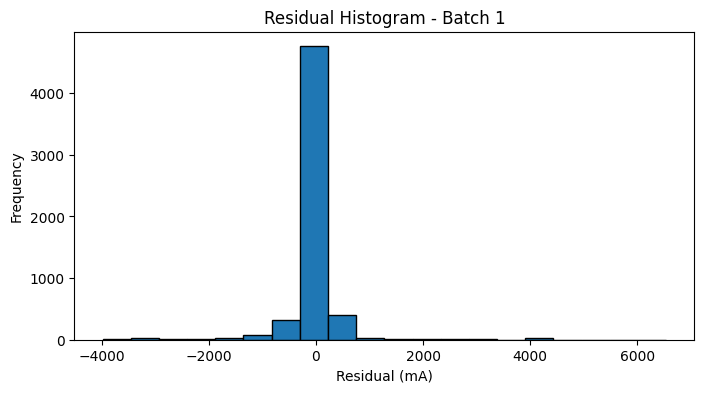

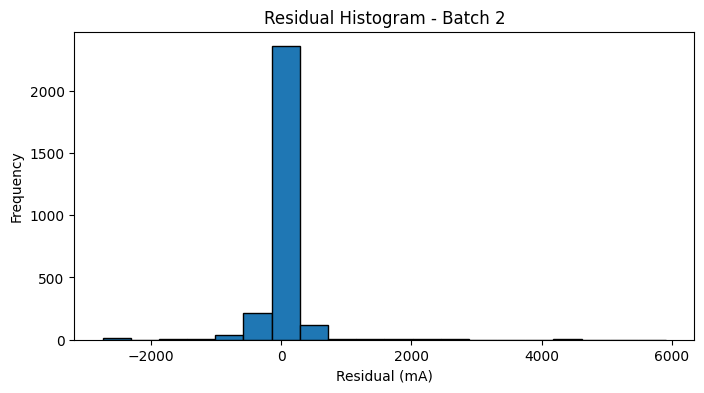

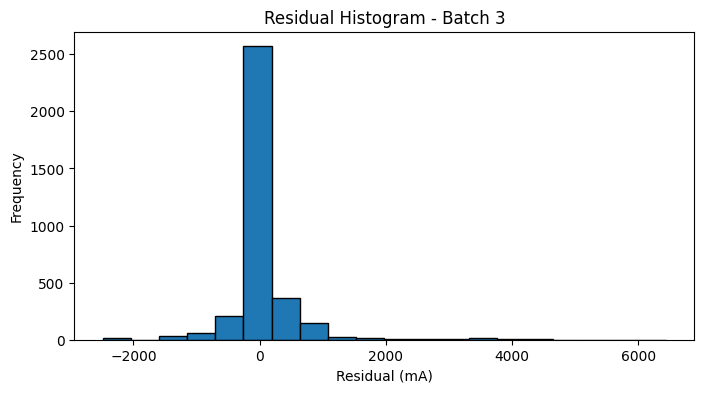

In [13]:
#Residual Histogram
for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=20, edgecolor='black')
    plt.xlabel("Residual (mA)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram - Batch {i}")

Correlation: 0.848722631861798


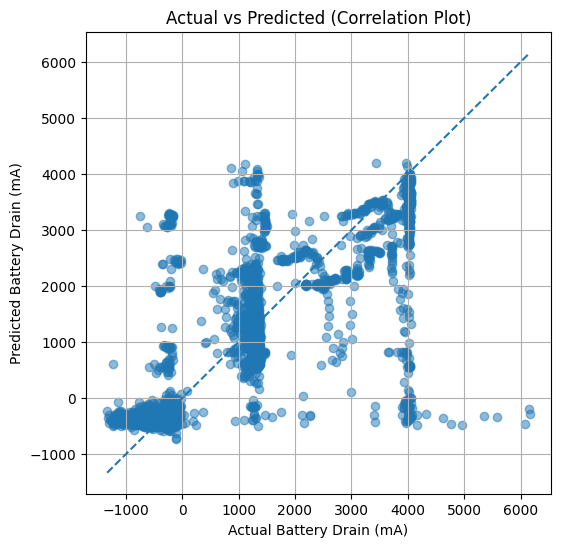

In [14]:
# Scatter Plot
actual_all = df_eval['battery_drain'].shift(-shift_step)
predicted_all = df_eval['predicted_drain_average']

valid_idx = actual_all.notna()
actual_all = actual_all[valid_idx].values
predicted_all = predicted_all[valid_idx].values

plt.figure(figsize=(6,6))
plt.scatter(actual_all, predicted_all, alpha=0.5)
min_val = min(actual_all.min(), predicted_all.min())
max_val = max(actual_all.max(), predicted_all.max())
plt.xlabel("Actual Battery Drain (mA)")
plt.ylabel("Predicted Battery Drain (mA)")
plt.title("Actual vs Predicted (Correlation Plot)")
plt.grid(True)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
print("Correlation:", np.corrcoef(actual_all, predicted_all)[0,1])

### Time Inference

#### Statistics

In [15]:
# Inference
df['inference_time_ms'].describe()

count    12039.000000
mean       247.100224
std        232.912418
min         96.026927
25%        165.893333
50%        206.964115
75%        275.657083
max      10902.668430
Name: inference_time_ms, dtype: float64

#### Graph

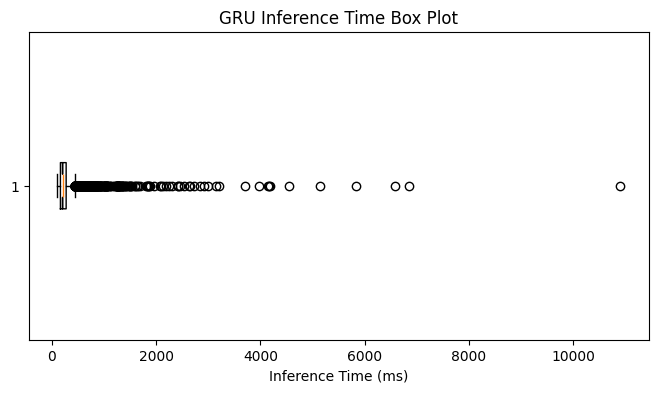

In [16]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['inference_time_ms'], notch=True, vert=False)
plt.title("GRU Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()

## CNN GRU

### Battery Drain Comparison

#### Statistics

In [17]:
df_cnn = pd.read_csv("./API_CNN_GRU.csv")
df_cnn.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,battery_drain,predicted_drain_average,inference_time_ms,batch
0,4/30/2026 10:09,42,66,33.4,84,0,2.372091,0.218891,1,24,-228,-284.06293,2524.913645,1
1,4/30/2026 10:09,37,66,33.4,84,0,1.236759,0.497219,1,24,-256,-310.48780,311.548437,1
2,4/30/2026 10:09,43,66,33.4,84,0,5.511522,253.716920,1,24,-236,-310.25890,222.169739,1
3,4/30/2026 10:09,43,67,33.4,84,0,1.819063,0.304796,1,24,-257,-319.87054,159.743697,1
4,4/30/2026 10:09,50,67,33.4,84,0,4.055333,2.990146,1,24,-413,-301.71088,437.896250,1


In [18]:
shift_step = 15
df_eval_cnn = df_cnn.copy()
df_eval_cnn['actual_aligned'] = df_eval_cnn['battery_drain'].shift(-shift_step)
df_eval_cnn = df_eval_cnn.dropna(subset=['actual_aligned', 'predicted_drain_average'])

In [19]:
df_eval_cnn[['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned            -103.137822
predicted_drain_average   -137.651291
dtype: float64

In [20]:
# Not Charging
df_eval_cnn[df_eval_cnn['battery_charging'] != 1][['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned            -279.241545
predicted_drain_average   -302.410626
dtype: float64

In [21]:
# Charging
df_eval_cnn[df_eval_cnn['battery_charging'] == 1][['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             1245.166667
predicted_drain_average    1123.797064
dtype: float64

In [22]:
charging_cnn = df_eval_cnn[df_eval_cnn['battery_charging'] == 1]
not_charging_cnn = df_eval_cnn[df_eval_cnn['battery_charging'] != 1]

In [23]:
act_c_cnn, pred_c_cnn, perc_c_cnn = percentage_diff(charging_cnn)
act_nc_cnn, pred_nc_cnn, perc_nc_cnn = percentage_diff(not_charging_cnn)
act_all_cnn, pred_all_cnn, perc_all_cnn = percentage_diff(df_eval_cnn)

In [24]:
print("== ALL ===")
print("Actual Mean:", act_all_cnn)
print("Predicted Mean:", pred_all_cnn)
print("Percentage Difference:", perc_all_cnn, "%")

print("\n=== CHARGING ===")
print("Actual Mean:", act_c_cnn)
print("Predicted Mean:", pred_c_cnn)
print("Percentage Difference:", perc_c_cnn, "%")

print("\n=== NOT CHARGING ===")
print("Actual Mean:", act_nc_cnn)
print("Predicted Mean:", pred_nc_cnn)
print("Percentage Difference:", perc_nc_cnn, "%")

== ALL ===
Actual Mean: -103.1378222560644
Predicted Mean: -137.6512908261286
Percentage Difference: 33.46344514079057 %

=== CHARGING ===
Actual Mean: 1245.1666666666667
Predicted Mean: 1123.7970638996233
Percentage Difference: 9.747257617484419 %

=== NOT CHARGING ===
Actual Mean: -279.2415447054483
Predicted Mean: -302.410625805682
Percentage Difference: 8.297146875001388 %


#### Graph

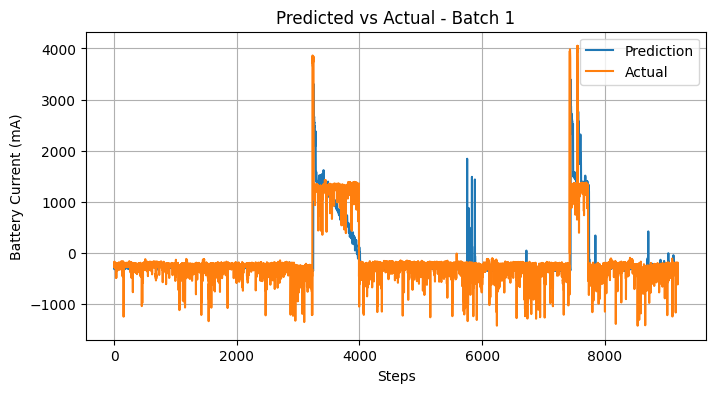

In [25]:
batch_num_cnn = df_cnn['batch'].nunique()

for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    plt.figure(figsize=(8, 4))
    plt.plot(predicted, label="Prediction")
    plt.plot(actual, label="Actual")
    plt.title(f"Predicted vs Actual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Battery Current (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

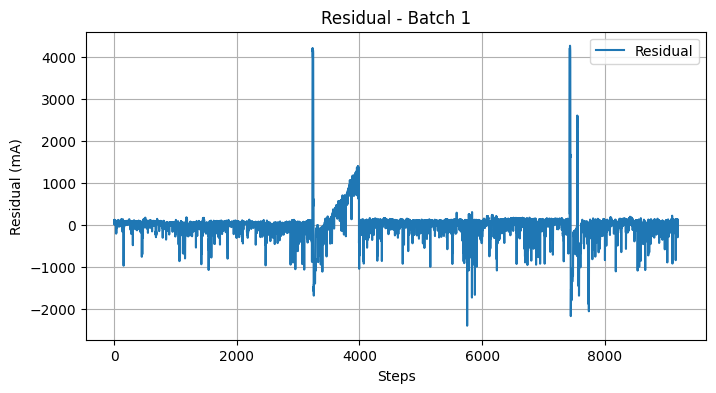

In [26]:
for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.plot(residual, label="Residual")
    plt.title(f"Residual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Residual (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

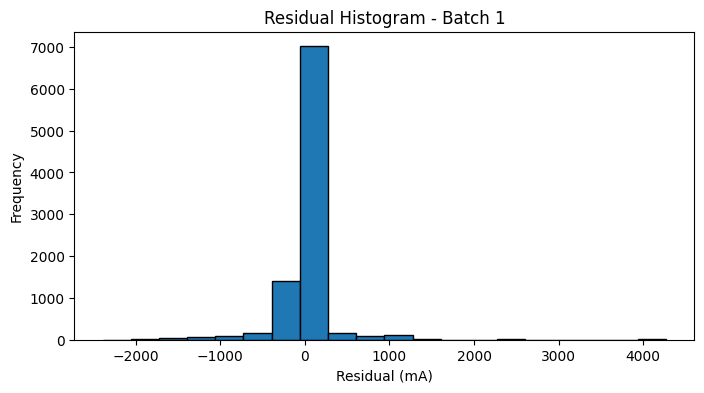

In [27]:
#Residual Histogram
for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=20, edgecolor='black')
    plt.xlabel("Residual (mA)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram - Batch {i}")

Correlation: 0.7920943194855915


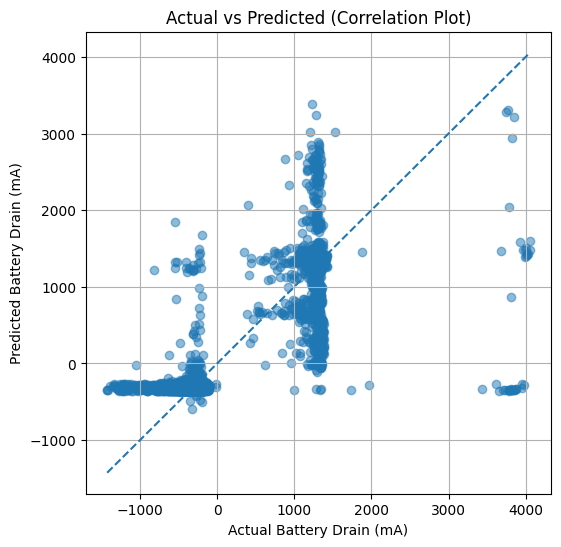

In [28]:
# Scatter Plot
actual_all = df_eval_cnn['battery_drain'].shift(-shift_step)
predicted_all = df_eval_cnn['predicted_drain_average']

valid_idx = actual_all.notna()
actual_all = actual_all[valid_idx].values
predicted_all = predicted_all[valid_idx].values

plt.figure(figsize=(6,6))
plt.scatter(actual_all, predicted_all, alpha=0.5)
min_val = min(actual_all.min(), predicted_all.min())
max_val = max(actual_all.max(), predicted_all.max())
plt.xlabel("Actual Battery Drain (mA)")
plt.ylabel("Predicted Battery Drain (mA)")
plt.title("Actual vs Predicted (Correlation Plot)")
plt.grid(True)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
print("Correlation:", np.corrcoef(actual_all, predicted_all)[0,1])

### Time Inference

#### Statistics

In [29]:
# Inference
df_cnn['inference_time_ms'].describe()

count    9208.000000
mean      229.395614
std       155.362416
min        99.926146
25%       165.999818
50%       201.854010
75%       261.934036
max      7380.025570
Name: inference_time_ms, dtype: float64

#### Graph

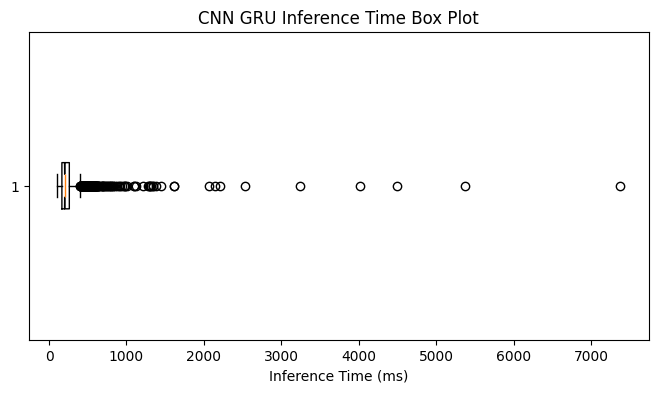

In [30]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_cnn['inference_time_ms'], notch=True, vert=False)
plt.title("CNN GRU Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()